In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content')  # Start from a safe directory first

import sys
sys.path.insert(0, '/content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/src')


Mounted at /content/drive


In [1]:
from google.colab import drive
drive.mount("/content/drive")

# CHANGE this to your repo folder
%cd /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications
build_and_test.sh   LICENSE	    README.md	 SUPPORT.md
CODE_OF_CONDUCT.md  pipelines	    SECURITY.md  tests
experiments	    pyproject.toml  src		 test.sh


In [ ]:
!pip install -e .

In [2]:
import slicegpt
from slicegpt import rotate, model_utils
print("slicegpt imported:", slicegpt.__file__)
print("rotate imported:", rotate.__file__)
print("model_utils imported:", model_utils.__file__)

slicegpt imported: /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/src/slicegpt/__init__.py
rotate imported: /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/src/slicegpt/rotate.py
model_utils imported: /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/src/slicegpt/model_utils.py


In [4]:
import os, textwrap

# Where to save logs and models in your Drive
BASE_RESULTS_DIR = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments"
LOG_DIR = os.path.join(BASE_RESULTS_DIR, "logs_opt_pca/Qwen2-0.5B")
MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_opt_pca/Qwen2-0.5B")


os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

In [2]:
import subprocess
from datetime import datetime

def run_slicegpt(dataset, sparsity):
    log_name = f"{dataset}_s{sparsity:.2f}".replace(".", "p") + ".txt" # 0.25 -> 0p25
    log_path = os.path.join(LOG_DIR, log_name)

    # if os.path.exists(log_path):
    #     print(f"[SKIP] Log already exists for {dataset}, sparsity={sparsity}: {log_path}")
    #     return

    save_dir = os.path.join(MODEL_DIR, f"{dataset}_s{sparsity:.2f}".replace(".", "p"))
    os.makedirs(save_dir, exist_ok=True)

    cmd = [
        "python",
        "/content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/experiments/run_slicegpt.py",
        "--model", "Qwen/Qwen2-0.5B",
        "--cal-dataset", dataset,
        "--save-dir", save_dir,
        "--sparsity", str(sparsity),
        "--device", "cuda:0",
        "--no-wandb",
        "--cal-batch-size", "8",
        "--save-hidden-states",  # <-- Add this flag
    ]

    print("\n=====================================================")
    print("Running:", " ".join(cmd))
    print("Log file:", log_path)
    print("Start:", datetime.now())
    print("=====================================================\n")

    with open(log_path, "w") as f:
        # Stream output to both cell and file
        process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            print(line, end="")   # to notebook
            f.write(line)         # to log file

    ret = process.wait()
    print("\nFinished with return code:", ret)
    print("End:", datetime.now())


In [5]:
#we do the first run just getting the rotation matrices with sparsity = 0.0
datasets = ["wikitext2"]
sparsities = [0.0]

for dataset in datasets:
    for s in sparsities:
        run_slicegpt(dataset, s)


Running: python /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/experiments/run_slicegpt.py --model Qwen/Qwen2-0.5B --cal-dataset wikitext2 --save-dir /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_opt_pca/Qwen2-0.5B/wikitext2_s0p00 --sparsity 0.0 --device cuda:0 --no-wandb --cal-batch-size 8 --save-hidden-states
Log file: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/logs_opt_pca/Qwen2-0.5B/wikitext2_s0p00.txt
Start: 2026-01-24 15:19:37.100695

Running SliceGPT experiment.
PyTorch device: cuda:0
Number of available cuda devices: 1
Loading Qwen/Qwen2-0.5B config and model weights from Hugging Face
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Loading model done
Loading dataset: wikitext2





Generating test split: 100%|██████████| 4358/4358 [00:00<00:00, 110560.68 examples/s]

Generating train split: 100%|██████████| 36718/36718 [00:00<00:00, 718957.53 examples/s]

Generating v

In [35]:
import os, textwrap

# Where to save logs and models in your Drive
BASE_RESULTS_DIR = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments"
LOG_DIR = os.path.join(BASE_RESULTS_DIR, "logs_opt_pca/Qwen2-0.5B")
MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_opt_pca/Qwen2-0.5B")
BASE_EVAL_DIR = os.path.join(BASE_RESULTS_DIR, "eval")
SQUAD_ROT = os.path.join(MODEL_DIR,"squad_s0p00/Qwen2-0.5B_0.0_rotation_matrices.pt")
WIKI_ROT = os.path.join(MODEL_DIR,"wikitext2_s0p00/Qwen2-0.5B_0.0_rotation_matrices.pt")
SQUAD_HIDDEN = os.path.join(MODEL_DIR,"squad_s0p00/Qwen2-0.5B_0.0_squad_hidden_states.pt")
WIKI_HIDDEN = os.path.join(MODEL_DIR,"wikitext2_s0p00/Qwen2-0.5B_0.0_wikitext2_hidden_states.pt")


os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

In [8]:
import torch
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [ ]:
pcas_squad = torch.load(SQUAD_ROT)
pcas_wikitext = torch.load(WIKI_ROT)

In [10]:
#let's upload the hidden state
hs_squad = torch.load(SQUAD_HIDDEN)

In [9]:
hs_wiki  = torch.load(WIKI_HIDDEN)

In [11]:
print(next(iter(hs_squad.values()))[0].shape)


torch.Size([8, 2042, 896])


In [ ]:
a = pcas_squad[21]["eigenvectors"]
b = pcas_wikitext[21]["eigenvectors"]

In [ ]:
from scipy.linalg import subspace_angles

def grassman_distance(A, B, k):
    sub_A = A[:, :k]
    sub_B = B[:, :k]

    angles = subspace_angles(sub_A, sub_B)

    grassman_dist = np.linalg.norm(angles)

    return grassman_dist

In [ ]:
def plot_grassman_vs_k(A, B, max_k=None, step=1):
    if max_k is None:
        max_k = min(A.shape[1], B.shape[1])

    k_values = list(range(1, max_k + step, step))
    distances = [grassman_distance(A, B, k) for k in k_values]

    plt.figure(figsize=(10, 6))
    plt.plot(k_values, distances, marker='o')
    plt.xlabel('k (Number of Principal Components)')
    plt.ylabel('Grassman Distance')
    plt.title('Grassman Distance vs Number of Principal Components')
    plt.grid()
    plt.show()

In [ ]:
plot_grassman_vs_k(a, b, max_k=768)

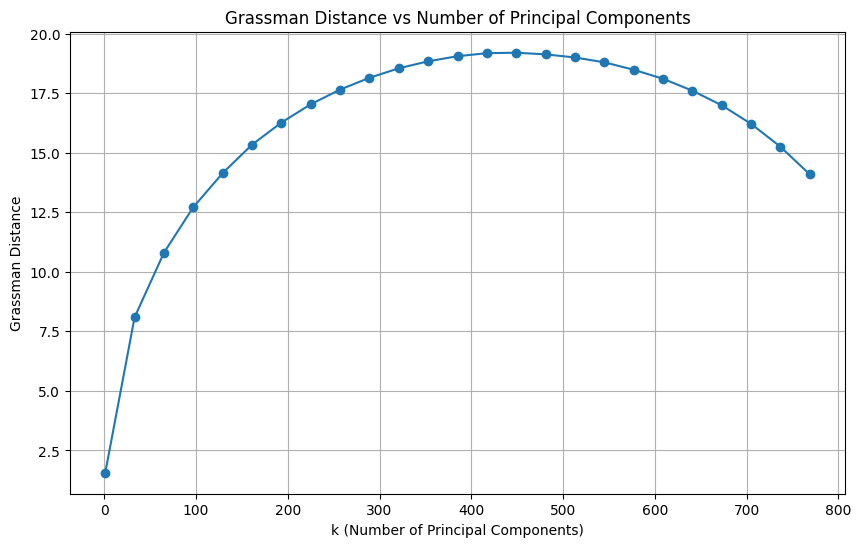

In [ ]:
a = pcas_squad[21]["eigenvectors"]
b = pcas_wikitext[21]["eigenvectors"]
plot_grassman_vs_k(a, b, max_k=768, step=32)
#result with layer = 21

In [ ]:
a = pcas_squad[5]["eigenvectors"]
b = pcas_wikitext[5]["eigenvectors"]

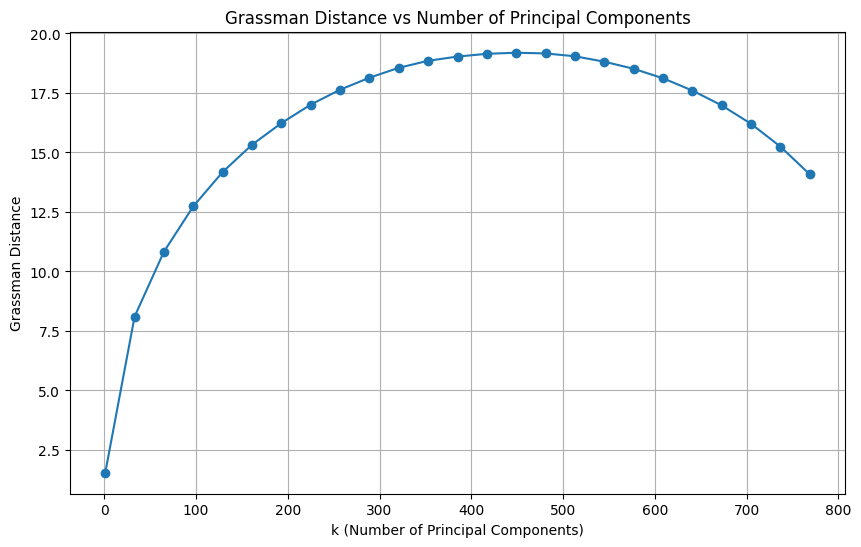

In [ ]:
plot_grassman_vs_k(a, b, max_k=768, step=32)
#result with layer 5

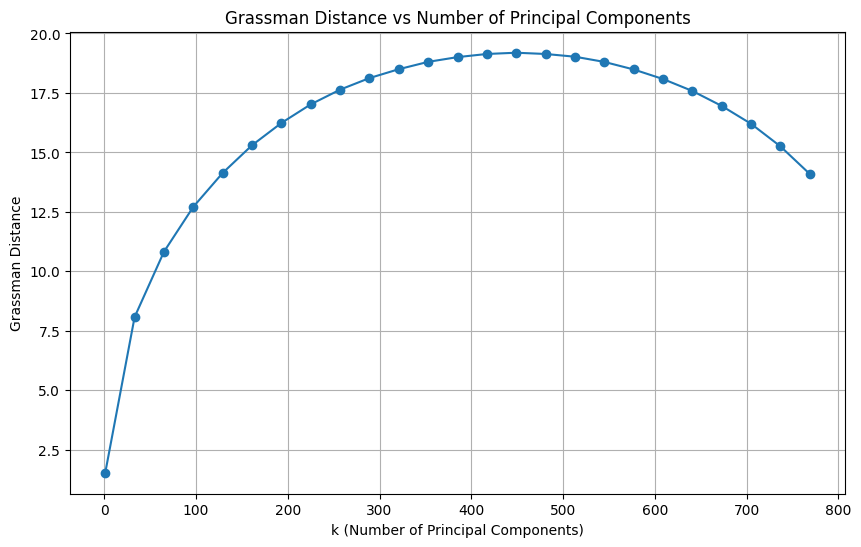

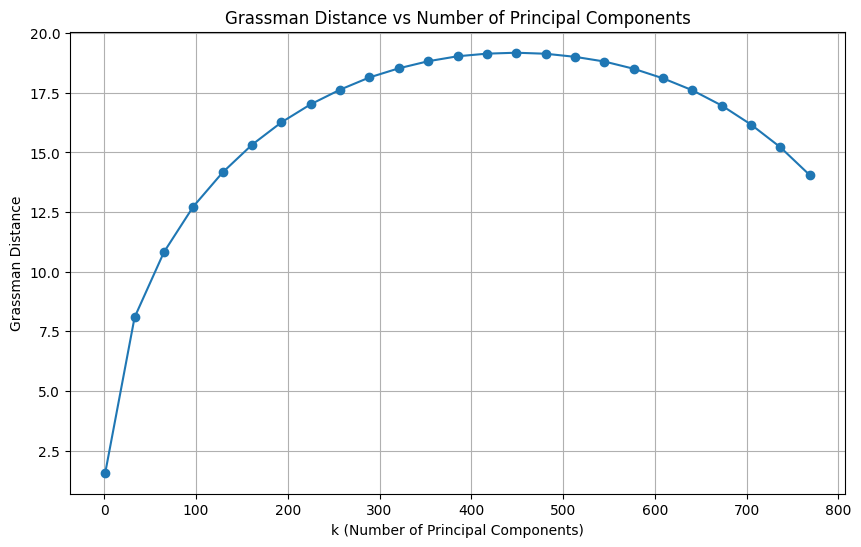

In [ ]:
a = pcas_squad[7]["eigenvectors"]
b = pcas_wikitext[7]["eigenvectors"]
plot_grassman_vs_k(a, b, max_k=768, step=32)
a = pcas_squad[23]["eigenvectors"]
b = pcas_wikitext[23]["eigenvectors"]
plot_grassman_vs_k(a, b, max_k=768, step=32)

In [ ]:
def pick(pcas, layer, typ):
    # typ in {"attn_output", "mlp_output", "embedding"}
    for e in pcas:
        if e["layer"] == layer and e["type"] == typ:
            return e["eigenvectors"]
    raise KeyError((layer, typ))

A7  = pick(pcas_squad,   layer=7,  typ="mlp_output")
B7  = pick(pcas_wikitext,layer=7,  typ="mlp_output")

A23 = pick(pcas_squad,   layer=23, typ="mlp_output")
B23 = pick(pcas_wikitext,layer=23, typ="mlp_output")


In [ ]:
print(A7.shape, B7.shape)
print(A23.shape, B23.shape)


torch.Size([896, 896]) torch.Size([896, 896])
torch.Size([896, 896]) torch.Size([896, 896])


In [ ]:
plot_grassman_vs_k(A7,  B7,  max_k=768, step=32)
plot_grassman_vs_k(A23, B23, max_k=768, step=32)


In [ ]:
def projector(V, k):
    Vk = V[:, :k]
    return Vk @ Vk.T

k = 256
P7  = projector(A7, k)
P23 = projector(A23, k)
print("||P7 - P23||_F:", np.linalg.norm(P7 - P23, ord="fro"))


||P7 - P23||_F: 19.119684081570135


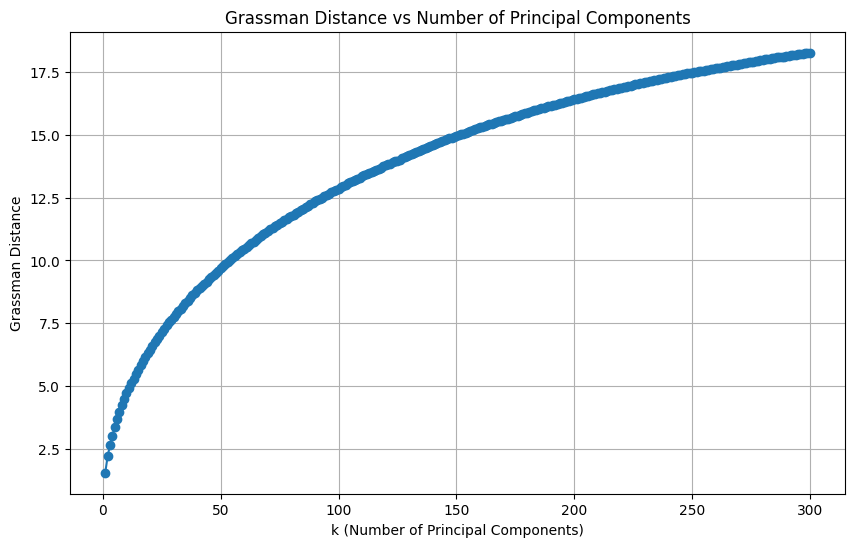

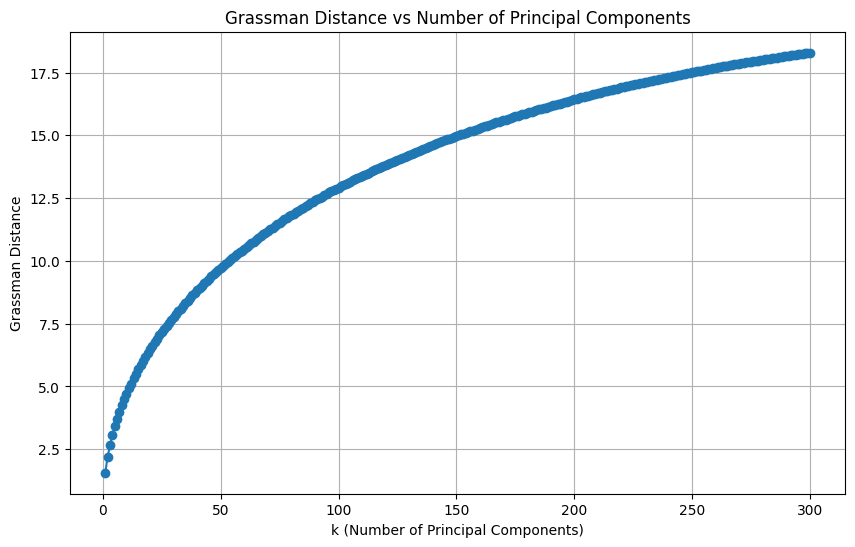

In [ ]:
plot_grassman_vs_k(A7,  B7,  max_k=300, step=1)
plot_grassman_vs_k(A23, B23, max_k=300, step=1)


In [ ]:
e7  = [e for e in pcas_squad if e["layer"]==7 and e["type"]=="mlp_output"][0]["eigenvectors"]
e23 = [e for e in pcas_squad if e["layer"]==23 and e["type"]=="mlp_output"][0]["eigenvectors"]
print("same object?", e7 is e23)


same object? False


In [ ]:
import torch

print("max |A7-A23|:", (A7 - A23).abs().max().item())
print("max |B7-B23|:", (B7 - B23).abs().max().item())


max |A7-A23|: 0.24029852881052824
max |B7-B23|: 0.22501561028110412


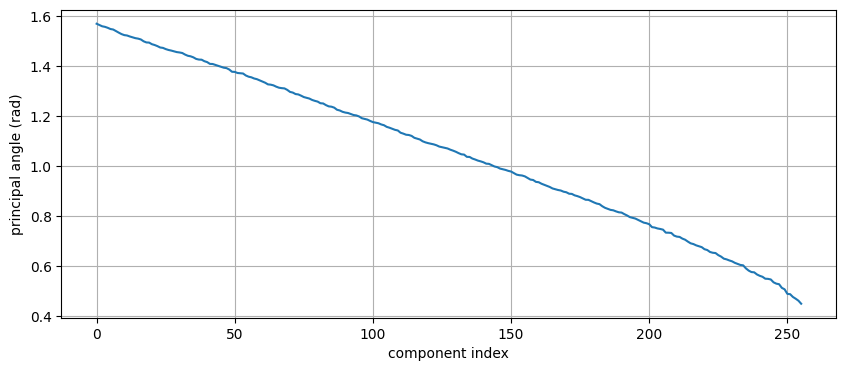

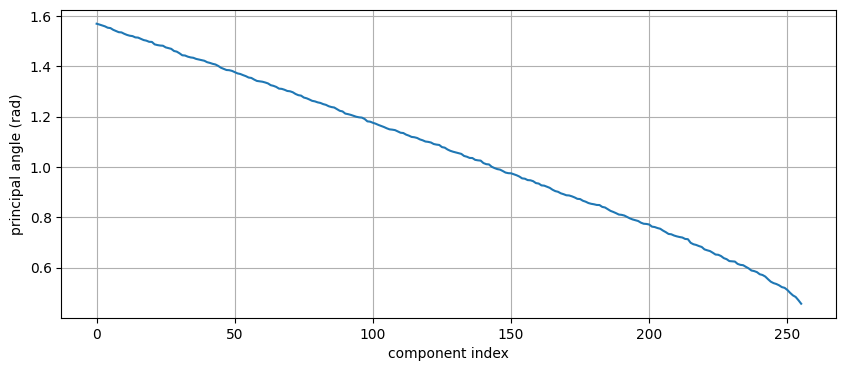

In [ ]:
def plot_angles(A, B, k=256):
    ang = subspace_angles(A[:, :k], B[:, :k])
    plt.figure(figsize=(10,4))
    plt.plot(ang)
    plt.xlabel("component index")
    plt.ylabel("principal angle (rad)")
    plt.grid(True)
    plt.show()

plot_angles(A7,  B7,  k=256)
plot_angles(A23, B23, k=256)


In [ ]:
def chordal_distance(A, B, k):
    sub_A = A[:, :k]
    sub_B = B[:, :k]

    s = np.linalg.svd(sub_A.T @ sub_B, compute_uv=False)

    chordal_distance = np.sqrt(k - np.sum(s**2))

    return chordal_distance

In [ ]:
def plot_chordal_dist_vs_k(A, B, max_k=None, step=1):
    if max_k is None:
        max_k = min(A.shape[1], B.shape[1])

    k_values = list(range(1, max_k + step, step))
    distances = [chordal_distance(A, B, k) for k in k_values]

    plt.figure(figsize=(10, 6))
    plt.plot(k_values, distances, marker='o')
    plt.xlabel('k (Number of Principal Components)')
    plt.ylabel('Chordal Distance')
    plt.title('Chordal Distance vs Number of Principal Components')
    plt.grid()
    plt.show()

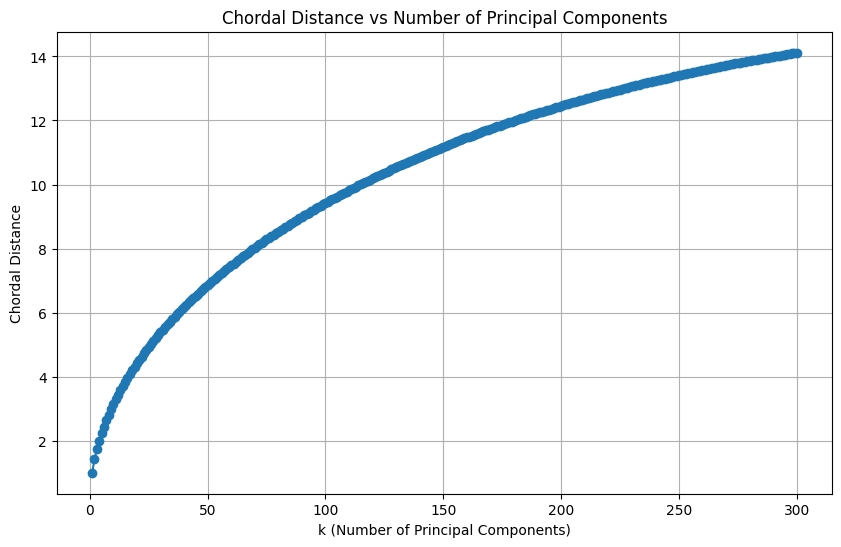

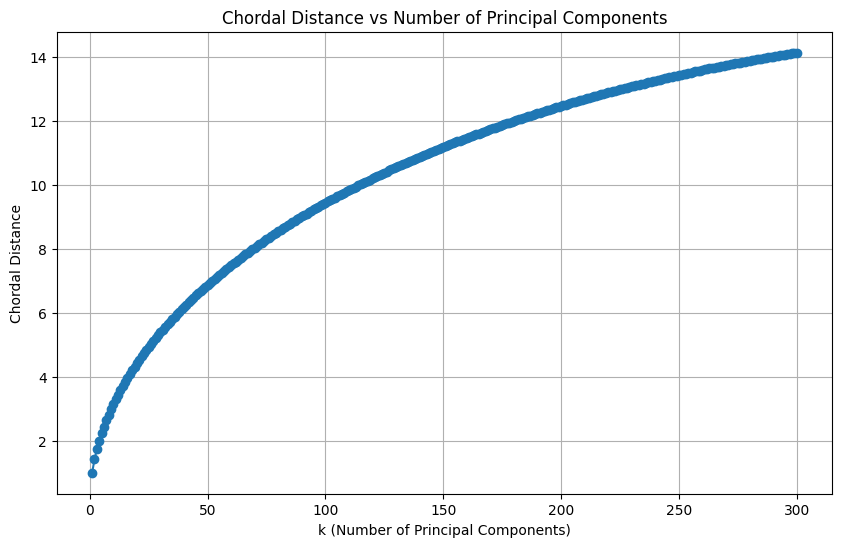

In [ ]:
plot_chordal_dist_vs_k(A7,  B7,  max_k=300, step=1)
plot_chordal_dist_vs_k(A23, B23, max_k=300, step=1)

In [ ]:
def proj_dist(A, B, k=256):
    Ak = A[:, :k]
    Bk = B[:, :k]
    PA = Ak @ Ak.T
    PB = Bk @ Bk.T
    return torch.linalg.norm(PA - PB).item()

print("dataset effect layer7 :", proj_dist(A7,  B7,  k=256))
print("dataset effect layer23:", proj_dist(A23, B23, k=256))


dataset effect layer7 : 19.10288542539659
dataset effect layer23: 19.12717600366587


In [ ]:
k=256
D7  = (A7[:, :k]  @ A7[:, :k].T)  - (B7[:, :k]  @ B7[:, :k].T)
D23 = (A23[:, :k] @ A23[:, :k].T) - (B23[:, :k] @ B23[:, :k].T)

print("||D7 - D23||_F:", torch.linalg.norm(D7 - D23).item())
print("||D7||_F:", torch.linalg.norm(D7).item(), "||D23||_F:", torch.linalg.norm(D23).item())


||D7 - D23||_F: 27.020139490795792
||D7||_F: 19.10288542539659 ||D23||_F: 19.12717600366587


In [ ]:
def plot_chordal_overlay(A7, B7, A23, B23, max_k=300, step=1):
    ks = range(1, max_k+1, step)
    d7  = [chordal_distance(A7,  B7,  k) for k in ks]
    d23 = [chordal_distance(A23, B23, k) for k in ks]

    plt.figure(figsize=(10,5))
    plt.plot(ks, d7,  label="Layer 7",  linewidth=2)
    plt.plot(ks, d23, label="Layer 23", linewidth=2, linestyle="--")
    plt.xlabel("k (number of principal components)")
    plt.ylabel("Chordal distance")
    plt.legend()
    plt.grid(True)
    plt.show()


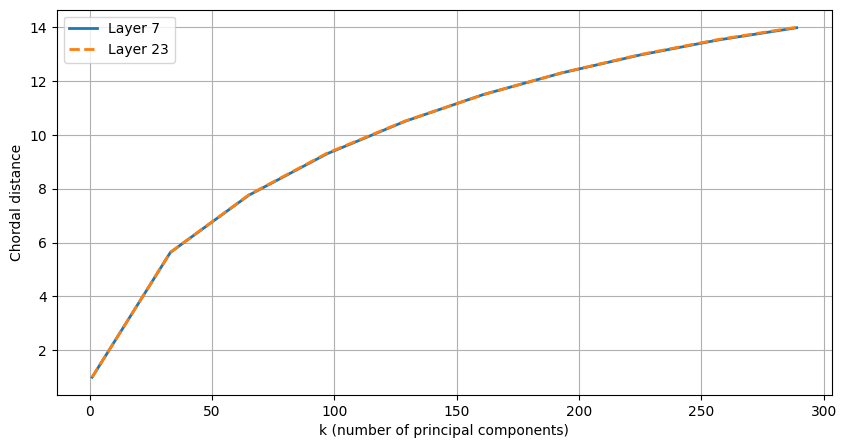

In [ ]:
plot_chordal_overlay(A7, B7, A23, B23, max_k=300, step=32)


In [ ]:
def plot_grassman_overlay(A7, B7, A23, B23, max_k=300, step=1):
    ks = range(1, max_k+1, step)
    d7  = [grassman_distance(A7,  B7,  k) for k in ks]
    d23 = [grassman_distance(A23, B23, k) for k in ks]

    plt.figure(figsize=(10,5))
    plt.plot(ks, d7,  label="Layer 7",  linewidth=2)
    plt.plot(ks, d23, label="Layer 23", linewidth=2, linestyle="--")
    plt.xlabel("k (number of principal components)")
    plt.ylabel("Chordal distance")
    plt.legend()
    plt.grid(True)
    plt.show()

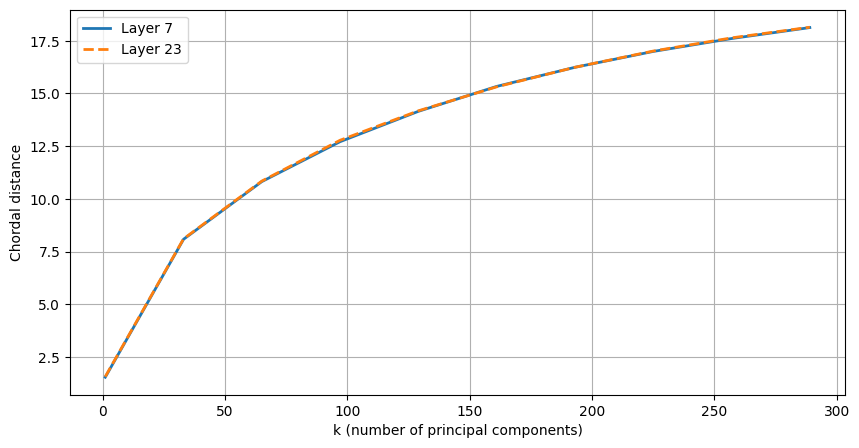

In [ ]:
plot_grassman_overlay(A7, B7, A23, B23, max_k=300, step=32)

In [ ]:
def plot_angle_overlay(A7, B7, A23, B23, k=256):
    ang7  = subspace_angles(A7[:, :k],  B7[:, :k])
    ang23 = subspace_angles(A23[:, :k], B23[:, :k])

    plt.figure(figsize=(10,5))
    plt.plot(ang7,  label="Layer 7",  linewidth=2)
    plt.plot(ang23, label="Layer 23", linewidth=2, linestyle="--")
    plt.xlabel("principal angle index")
    plt.ylabel("principal angle (rad)")
    plt.legend()
    plt.grid(True)
    plt.show()


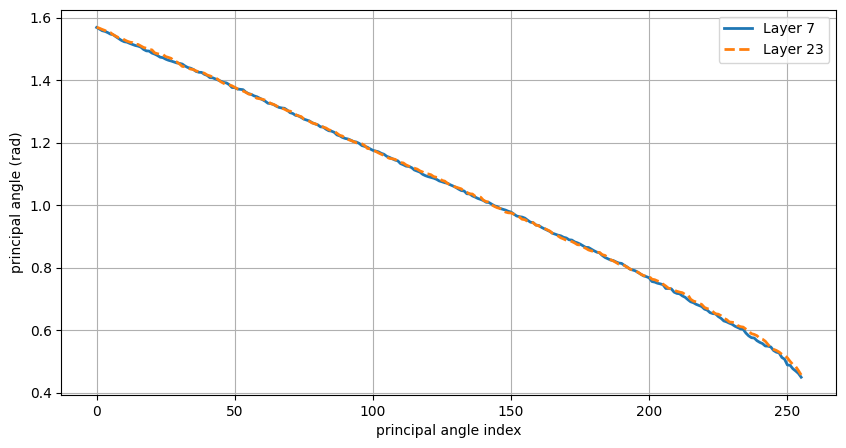

In [ ]:
plot_angle_overlay(A7, B7, A23, B23, k=256)


In [12]:
import torch
import math

EPS = 1e-12

def spectrum_from_hidden(X: torch.Tensor):
    """
    X: [T, d] hidden states (float32/float64 recommended)
    returns:
      lam: [d] eigenvalues of covariance (sorted desc)
      p:   [d] normalized spectrum (probabilities)
    """
    X = X.float()
    Xc = X - X.mean(dim=0, keepdim=True)               # [T, d]
    # SVD on centered activations
    # full_matrices=False makes this efficient
    _, S, _ = torch.linalg.svd(Xc, full_matrices=False)  # S: [min(T,d)]
    T = Xc.shape[0]
    lam = (S**2) / max(T - 1, 1)                       # covariance eigenvalues
    # pad to length d if T<d (missing eigenvalues are 0)
    d = Xc.shape[1]
    if lam.numel() < d:
        lam = torch.cat([lam, torch.zeros(d - lam.numel(), device=lam.device)])
    lam, _ = torch.sort(lam, descending=True)
    p = lam / (lam.sum() + EPS)
    return lam, p

def js_divergence(p, q):
    """Jensen–Shannon divergence in nats (use /log(2) for bits)."""
    p = torch.clamp(p, min=EPS)
    q = torch.clamp(q, min=EPS)
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)
    kl_pm = (p * (p / m).log()).sum()
    kl_qm = (q * (q / m).log()).sum()
    return 0.5 * (kl_pm + kl_qm)

def effective_rank_entropy(p):
    p = torch.clamp(p, min=EPS)
    p = p / p.sum()
    H = -(p * p.log()).sum()
    return torch.exp(H)

def participation_ratio(lam):
    lam = torch.clamp(lam, min=0.0)
    return (lam.sum()**2) / (torch.sum(lam**2) + EPS)

def wasserstein_1d(p, q):
    """
    1D Wasserstein distance between discrete distributions on indices 0..d-1.
    This measures 'shape shift' across the spectrum.
    """
    p = torch.clamp(p, min=0.0); p = p / (p.sum() + EPS)
    q = torch.clamp(q, min=0.0); q = q / (q.sum() + EPS)
    cdf_p = torch.cumsum(p, dim=0)
    cdf_q = torch.cumsum(q, dim=0)
    return torch.sum(torch.abs(cdf_p - cdf_q))


In [13]:
import torch, numpy as np, pandas as pd, re, matplotlib.pyplot as plt

def to_token_matrix(list_of_tensors):
    chunks = []
    for t in list_of_tensors:
        x = t.detach().cpu()
        x = x.reshape(-1, x.shape[-1])   # [B,S,d] -> [B*S,d]
        chunks.append(x.float())
    return torch.cat(chunks, dim=0)       # [T,d]

def match_and_cap(Xa, Xb, max_tokens=20000, seed=0):
    T = min(Xa.shape[0], Xb.shape[0], max_tokens)
    rng = np.random.default_rng(seed)
    ia = rng.choice(Xa.shape[0], size=T, replace=False)
    ib = rng.choice(Xb.shape[0], size=T, replace=False)
    return Xa[ia], Xb[ib]

def parse_layer_idx(key):
    if key == "embedding_output": return -1
    m = re.search(r"layer_(\d+)_", key)
    return int(m.group(1)) if m else None

def pos_type(key):
    if key == "embedding_output": return "embed"
    if "attn_output" in key: return "attn"
    if "mlp_output" in key: return "mlp"
    if key.endswith("_output"): return "layer_out"
    return "other"

def compute_df(hsA, hsB, max_tokens=20000):
    rows = []
    common_keys = sorted(set(hsA.keys()) & set(hsB.keys()))
    for k in common_keys:
        Xa = to_token_matrix(hsA[k])
        Xb = to_token_matrix(hsB[k])
        Xa, Xb = match_and_cap(Xa, Xb, max_tokens=max_tokens, seed=0)

        lamA, pA = spectrum_from_hidden(Xa)
        lamB, pB = spectrum_from_hidden(Xb)

        rows.append({
            "key": k,
            "layer": parse_layer_idx(k),
            "pos": pos_type(k),
            "JS": js_divergence(pA, pB).item(),
            "W1": wasserstein_1d(pA, pB).item(),
            "r_eff_A": effective_rank_entropy(pA).item(),
            "r_eff_B": effective_rank_entropy(pB).item(),
            "r_eff_diff": (effective_rank_entropy(pA) - effective_rank_entropy(pB)).item(),
            "r_pr_A": participation_ratio(lamA).item(),
            "r_pr_B": participation_ratio(lamB).item(),
            "r_pr_diff": (participation_ratio(lamA) - participation_ratio(lamB)).item(),
        })
    df = pd.DataFrame(rows).sort_values(["layer", "pos", "key"])
    return df

df = compute_df(hs_squad, hs_wiki, max_tokens=20000)
df.head()


,key,layer,pos,JS,W1,r_eff_A,r_eff_B,r_eff_diff,r_pr_A,r_pr_B,r_pr_diff
0,embedding_output,-1,embed,0.003037,9.538227,191.503616,190.661880,0.841736,20.216166,25.083456,-4.867290
1,layer_0_attn_output,0,attn,0.002188,13.352914,314.401367,284.551758,29.849609,60.288727,62.636894,-2.348167
2,layer_0_mlp_output,0,mlp,0.000484,5.453440,268.132355,252.607285,15.525070,96.603455,92.673454,3.930000
23,layer_1_attn_output,1,attn,0.000389,4.866907,283.241089,271.460327,11.780762,95.020203,94.397285,0.622917
24,layer_1_mlp_output,1,mlp,0.000283,4.876584,315.664124,303.269104,12.395020,111.088898,107.764458,3.324440


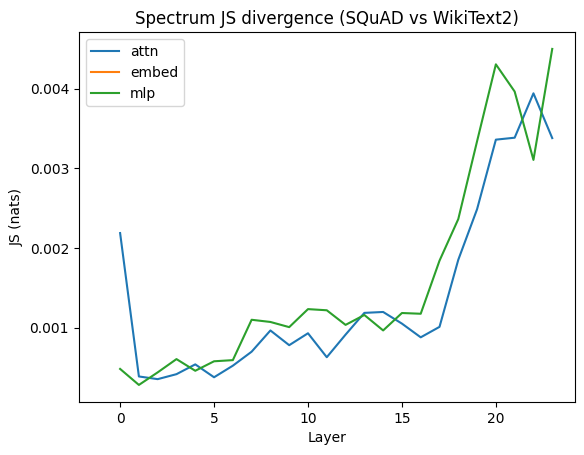

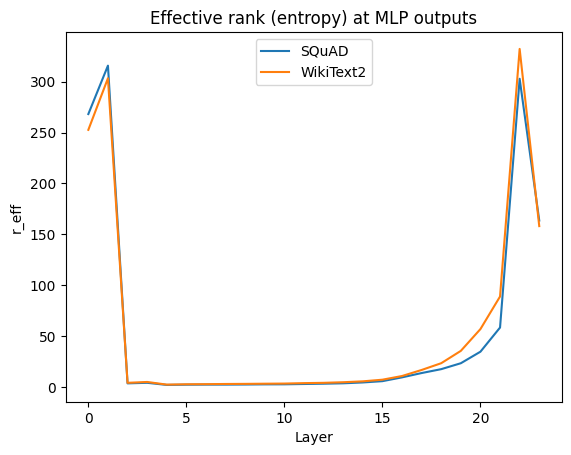

In [14]:
dfp = df[df["layer"].notna()]

plt.figure()
for p in sorted(dfp["pos"].unique()):
    sub = dfp[dfp["pos"] == p]
    plt.plot(sub["layer"], sub["JS"], label=p)
plt.title("Spectrum JS divergence (SQuAD vs WikiText2)")
plt.xlabel("Layer"); plt.ylabel("JS (nats)")
plt.legend(); plt.show()

plt.figure()
sub = dfp[dfp["pos"] == "mlp"]
plt.plot(sub["layer"], sub["r_eff_A"], label="SQuAD")
plt.plot(sub["layer"], sub["r_eff_B"], label="WikiText2")
plt.title("Effective rank (entropy) at MLP outputs")
plt.xlabel("Layer"); plt.ylabel("r_eff")
plt.legend(); plt.show()


In [15]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

def to_token_matrix(list_of_tensors):
    # list of [B,S,d] -> [T,d]
    chunks = []
    for t in list_of_tensors:
        x = t.detach().cpu().reshape(-1, t.shape[-1]).float()
        chunks.append(x)
    return torch.cat(chunks, dim=0)

def match_and_cap(Xa, Xb, max_tokens=20000, seed=0):
    T = min(Xa.shape[0], Xb.shape[0], max_tokens)
    rng = np.random.default_rng(seed)
    ia = rng.choice(Xa.shape[0], size=T, replace=False)
    ib = rng.choice(Xb.shape[0], size=T, replace=False)
    return Xa[ia], Xb[ib]

def is_mlp_key(k):
    return ("mlp_output" in k) or (k.endswith("_mlp_output"))

def layer_idx_from_key(k):
    m = re.search(r"layer_(\d+)_", k)
    return int(m.group(1)) if m else None

def recon_error_curve_from_lam(lam, ks):
    # lam sorted desc, error(k) = sum_{i>k} lam_i
    lam = lam.cpu()
    total = lam.sum()
    # prefix sums for top-k kept variance
    prefix = torch.cumsum(lam, dim=0)
    errs = []
    for k in ks:
        kept = prefix[k-1] if k > 0 else torch.tensor(0.0)
        errs.append((total - kept).item())
    return np.array(errs)

def run_recon_analysis(hsA, hsB, layers=(18,19,20,21,22,23), max_tokens=20000, seed=0,
                       ks=None, normalize=True):
    """
    normalize=True -> plot residual fraction: sum_{i>k} lam_i / sum_i lam_i
    normalize=False -> plot absolute residual energy
    """
    if ks is None:
        ks = list(range(0, 257, 8))  # adjust as you like

    rows = []
    common_keys = set(hsA.keys()) & set(hsB.keys())

    # pick MLP keys for requested layers
    mlp_keys = []
    for k in common_keys:
        if not is_mlp_key(k):
            continue
        li = layer_idx_from_key(k)
        if li in layers:
            mlp_keys.append((li, k))
    mlp_keys.sort()

    if not mlp_keys:
        raise ValueError("No MLP keys found for the requested layers. Check key names.")

    for li, k in mlp_keys:
        XA = to_token_matrix(hsA[k])
        XB = to_token_matrix(hsB[k])
        XA, XB = match_and_cap(XA, XB, max_tokens=max_tokens, seed=seed)

        lamA, _ = spectrum_from_hidden(XA)
        lamB, _ = spectrum_from_hidden(XB)

        errA = recon_error_curve_from_lam(lamA, ks)
        errB = recon_error_curve_from_lam(lamB, ks)

        if normalize:
            errA = errA / (lamA.sum().item() + 1e-12)
            errB = errB / (lamB.sum().item() + 1e-12)

        for k_val, eA, eB in zip(ks, errA, errB):
            rows.append({
                "layer": li,
                "k": k_val,
                "err_A": eA,
                "err_B": eB,
                "err_diff": eB - eA,  # B - A
                "key": k
            })

    return pd.DataFrame(rows), mlp_keys

# Run it
layers_to_check = [18,19,20,21,22,23]
df_recon, used_keys = run_recon_analysis(
    hs_squad, hs_wiki,
    layers=layers_to_check,
    max_tokens=20000,
    seed=0,
    ks=list(range(0, 513, 16)),   # choose k grid (0..512 step 16)
    normalize=True                # residual fraction is easiest to compare
)

print("Used keys:")
for li, k in used_keys:
    print(li, k)

df_recon.head()


Used keys:
18 layer_18_mlp_output
19 layer_19_mlp_output
20 layer_20_mlp_output
21 layer_21_mlp_output
22 layer_22_mlp_output
23 layer_23_mlp_output


,layer,k,err_A,err_B,err_diff,key
0,18,0,1.000000,1.000000,0.000000,layer_18_mlp_output
1,18,16,0.277957,0.306858,0.028901,layer_18_mlp_output
2,18,32,0.228466,0.264160,0.035694,layer_18_mlp_output
3,18,48,0.197200,0.236482,0.039282,layer_18_mlp_output
4,18,64,0.175636,0.215973,0.040337,layer_18_mlp_output


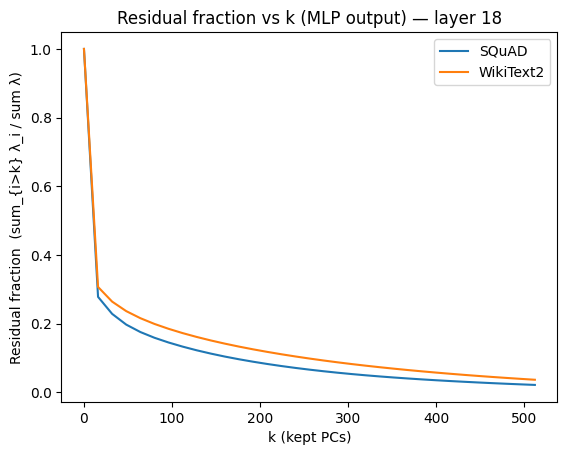

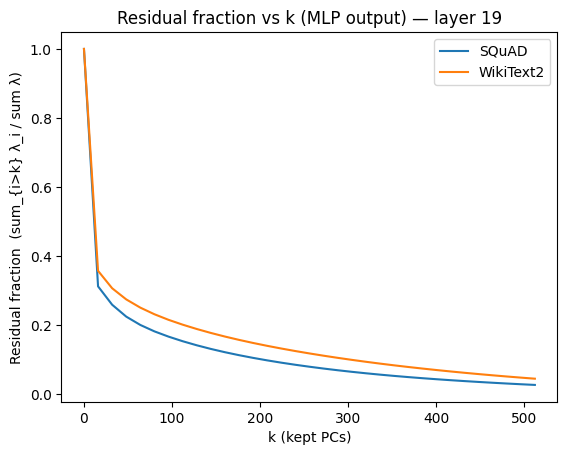

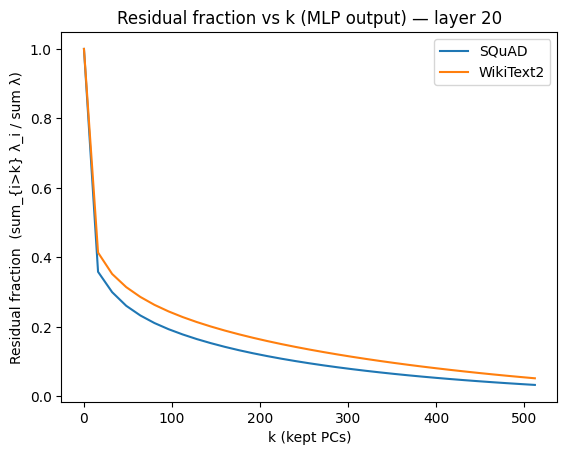

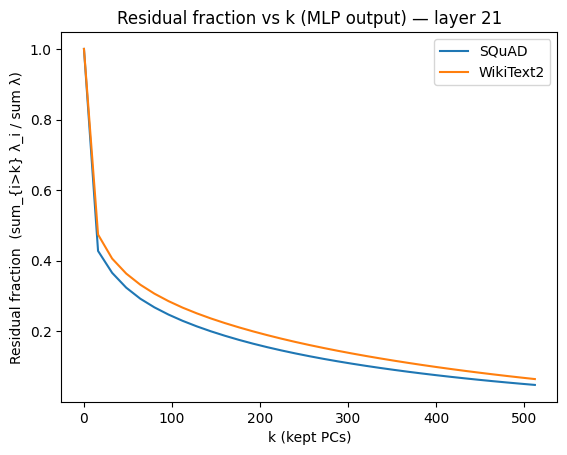

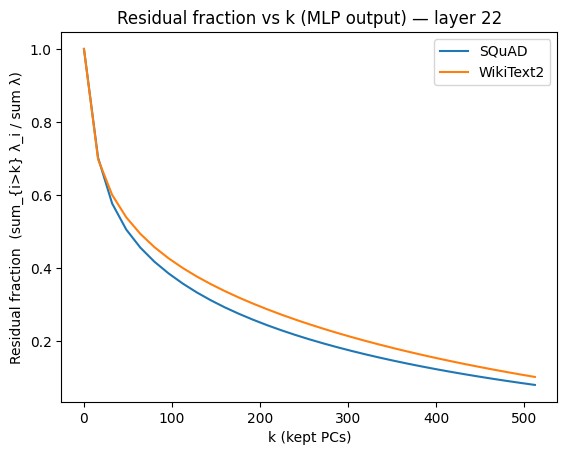

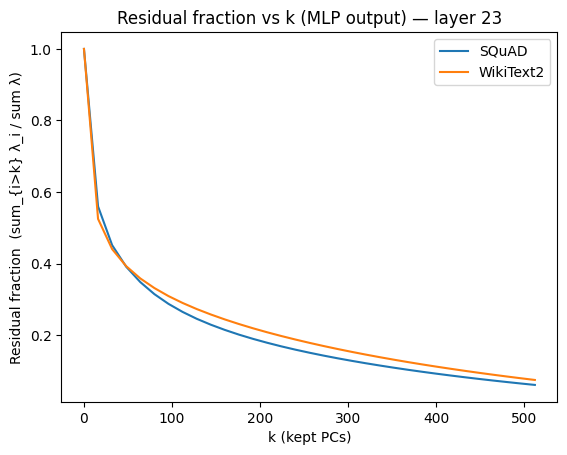

In [19]:
for li in sorted(df_recon["layer"].unique()):
    sub = df_recon[df_recon["layer"] == li].sort_values("k")
    plt.figure()
    plt.plot(sub["k"], sub["err_A"], label="SQuAD")
    plt.plot(sub["k"], sub["err_B"], label="WikiText2")
    plt.title(f"Residual fraction vs k (MLP output) — layer {li}")
    plt.xlabel("k (kept PCs)")
    plt.ylabel("Residual fraction  (sum_{i>k} λ_i / sum λ)")
    plt.legend()
    plt.show()


In [20]:
def k_for_threshold(sub, thr=0.10):
    # smallest k where residual <= thr
    sub = sub.sort_values("k")
    ok = sub[sub["err_A"] <= thr]
    kA = int(ok["k"].iloc[0]) if len(ok) else None
    ok = sub[sub["err_B"] <= thr]
    kB = int(ok["k"].iloc[0]) if len(ok) else None
    return kA, kB

thr = 0.10
summary = []
for li in sorted(df_recon["layer"].unique()):
    sub = df_recon[df_recon["layer"] == li]
    # compute separately for A and B
    subA = sub[["k","err_A"]].rename(columns={"err_A":"err"})
    subB = sub[["k","err_B"]].rename(columns={"err_B":"err"})
    kA = subA[subA["err"] <= thr]["k"].min()
    kB = subB[subB["err"] <= thr]["k"].min()
    summary.append({"layer": li, f"k@{thr} (SQuAD)": kA, f"k@{thr} (WikiText2)": kB, "delta_k": (kB - kA) if (kA==kA and kB==kB) else None})

df_k = pd.DataFrame(summary)
df_k


,layer,k@0.1 (SQuAD),k@0.1 (WikiText2),delta_k
0,18,176,256.0,80.0
1,19,208,304.0,96.0
2,20,256,352.0,96.0
3,21,336,400.0,64.0
4,22,464,NaN,NaN
5,23,384,448.0,64.0


In [24]:
d = 896
SPARSITIES = [0.0, 0.10, 0.25, 0.40, 0.60]   # change to your actual list
Ks = {s: int(round((1 - s) * d)) for s in SPARSITIES}
Ks


{0.0: 896, 0.1: 806, 0.25: 672, 0.4: 538, 0.6: 358}

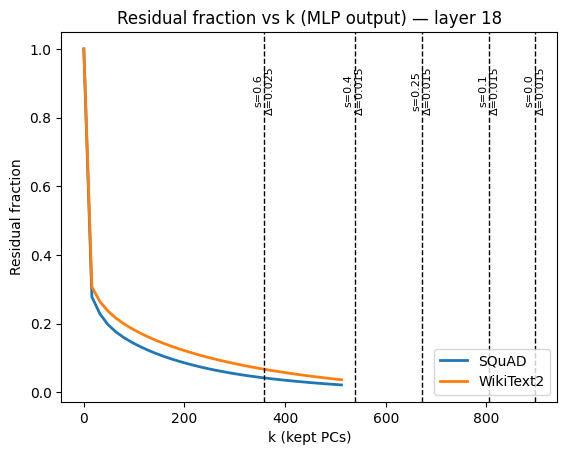

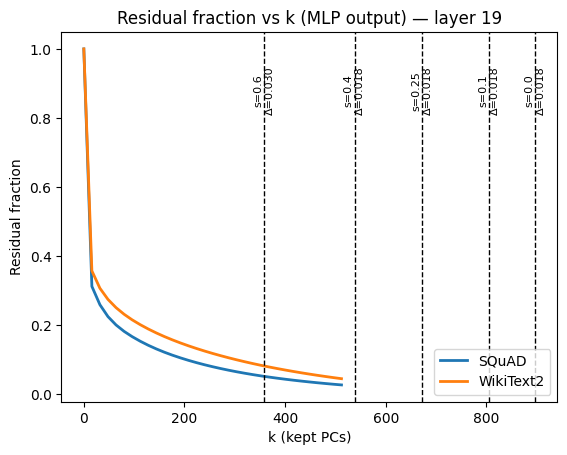

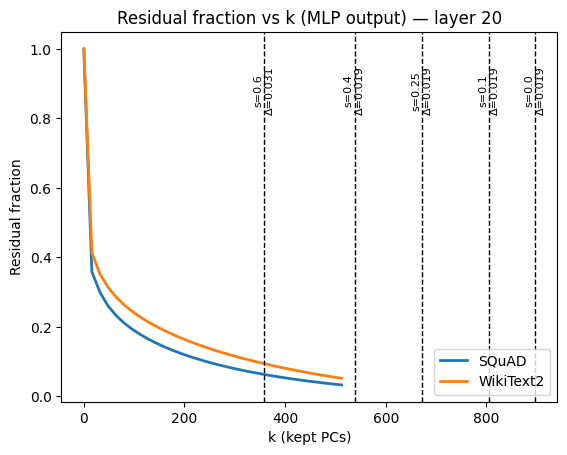

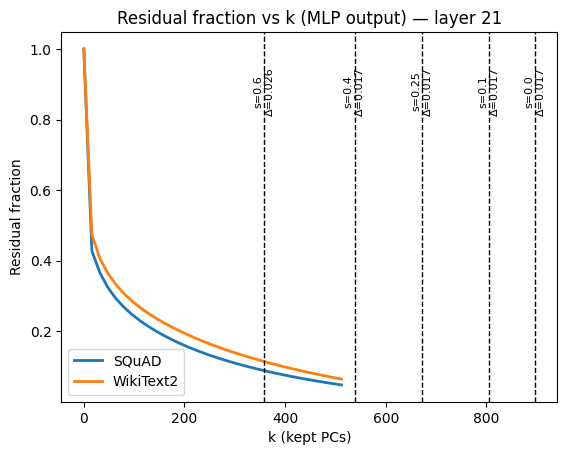

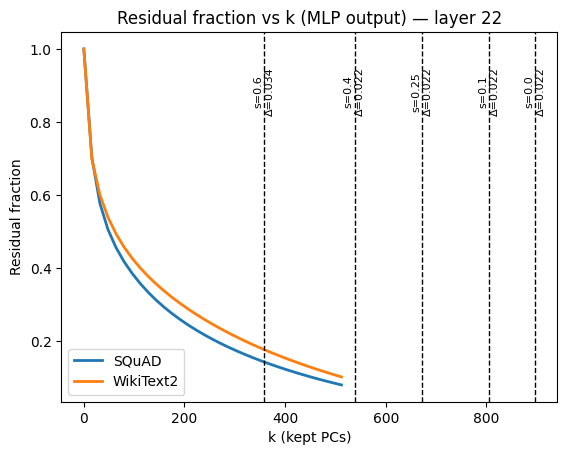

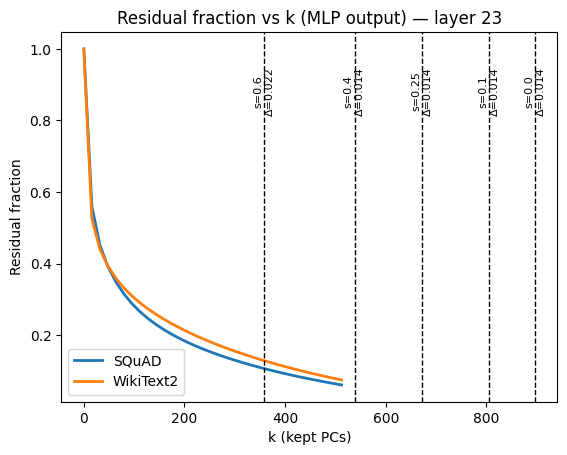

In [25]:
import numpy as np
import matplotlib.pyplot as plt

for li in sorted(df_recon["layer"].unique()):
    sub = df_recon[df_recon["layer"] == li].sort_values("k")

    plt.figure()
    plt.plot(sub["k"], sub["err_A"], label="SQuAD", linewidth=2)
    plt.plot(sub["k"], sub["err_B"], label="WikiText2", linewidth=2)

    for s, k_op in Ks.items():
        # interpolate residuals at k_op
        errA = np.interp(k_op, sub["k"], sub["err_A"])
        errB = np.interp(k_op, sub["k"], sub["err_B"])
        delta = errB - errA

        plt.axvline(k_op, color="black", linestyle="--", linewidth=1)
        plt.text(k_op, 0.95, f"s={s}\nΔ={delta:.3f}", rotation=90,
                 va="top", ha="center", fontsize=8)

    plt.title(f"Residual fraction vs k (MLP output) — layer {li}")
    plt.xlabel("k (kept PCs)")
    plt.ylabel("Residual fraction")
    plt.legend()
    plt.show()


In [23]:
rows = []
for li in sorted(df_recon["layer"].unique()):
    sub = df_recon[df_recon["layer"] == li].sort_values("k")
    for s, k_op in Ks.items():
        errA = np.interp(k_op, sub["k"], sub["err_A"])
        errB = np.interp(k_op, sub["k"], sub["err_B"])
        rows.append({
            "layer": li,
            "sparsity": s,
            "k": k_op,
            "residual@k (SQuAD)": errA,
            "residual@k (WikiText2)": errB,
            "Δresidual (WikiText − SQuAD)": errB - errA
        })

df_op = pd.DataFrame(rows).sort_values(["sparsity","layer"])
df_op


,layer,sparsity,k,residual@k (SQuAD),residual@k (WikiText2),Δresidual (WikiText − SQuAD)
0,18,0.10,806,0.021591,0.036639,0.015048
4,19,0.10,806,0.026078,0.044143,0.018065
8,20,0.10,806,0.032891,0.051973,0.019081
12,21,0.10,806,0.048063,0.064639,0.016577
16,22,0.10,806,0.080078,0.101924,0.021846
20,23,0.10,806,0.060489,0.074368,0.013879
1,18,0.25,672,0.021591,0.036639,0.015048
5,19,0.25,672,0.026078,0.044143,0.018065
9,20,0.25,672,0.032891,0.051973,0.019081
13,21,0.25,672,0.048063,0.064639,0.016577


In [ ]:
#I think that the following 2 cells are wrong because we are using sparsity = 0.0
OPERATING_K = 448  # change if needed

for li in sorted(df_recon["layer"].unique()):
    sub = df_recon[df_recon["layer"] == li].sort_values("k")

    # interpolate residuals at operating k
    errA = np.interp(OPERATING_K, sub["k"], sub["err_A"])
    errB = np.interp(OPERATING_K, sub["k"], sub["err_B"])
    delta = errB - errA

    plt.figure()
    plt.plot(sub["k"], sub["err_A"], label="SQuAD", linewidth=2)
    plt.plot(sub["k"], sub["err_B"], label="WikiText2", linewidth=2)

    plt.axvline(
        OPERATING_K,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=f"k = {OPERATING_K}"
    )

    plt.scatter([OPERATING_K], [errA], color="blue")
    plt.scatter([OPERATING_K], [errB], color="orange")

    plt.title(f"Residual fraction vs k (MLP output) — layer {li}")
    plt.xlabel("k (kept PCs)")
    plt.ylabel("Residual fraction")

    plt.text(
        OPERATING_K * 0.55,
        max(errA, errB) * 1.05,
        f"Δresidual ≈ {delta:.3f}",
        fontsize=10
    )

    plt.legend()
    plt.show()


In [27]:
summary = []

for li in sorted(df_recon["layer"].unique()):
    sub = df_recon[df_recon["layer"] == li].sort_values("k")
    errA = np.interp(OPERATING_K, sub["k"], sub["err_A"])
    errB = np.interp(OPERATING_K, sub["k"], sub["err_B"])

    summary.append({
        "layer": li,
        "residual@k (SQuAD)": errA,
        "residual@k (WikiText2)": errB,
        "Δresidual (WikiText − SQuAD)": errB - errA
    })

df_operating = pd.DataFrame(summary)
df_operating


,layer,residual@k (SQuAD),residual@k (WikiText2),Δresidual (WikiText − SQuAD)
0,18,0.028662,0.047679,0.019017
1,19,0.034720,0.057511,0.022792
2,20,0.043551,0.067380,0.023829
3,21,0.062693,0.083013,0.020320
4,22,0.103062,0.129831,0.026769
5,23,0.077391,0.094510,0.017119


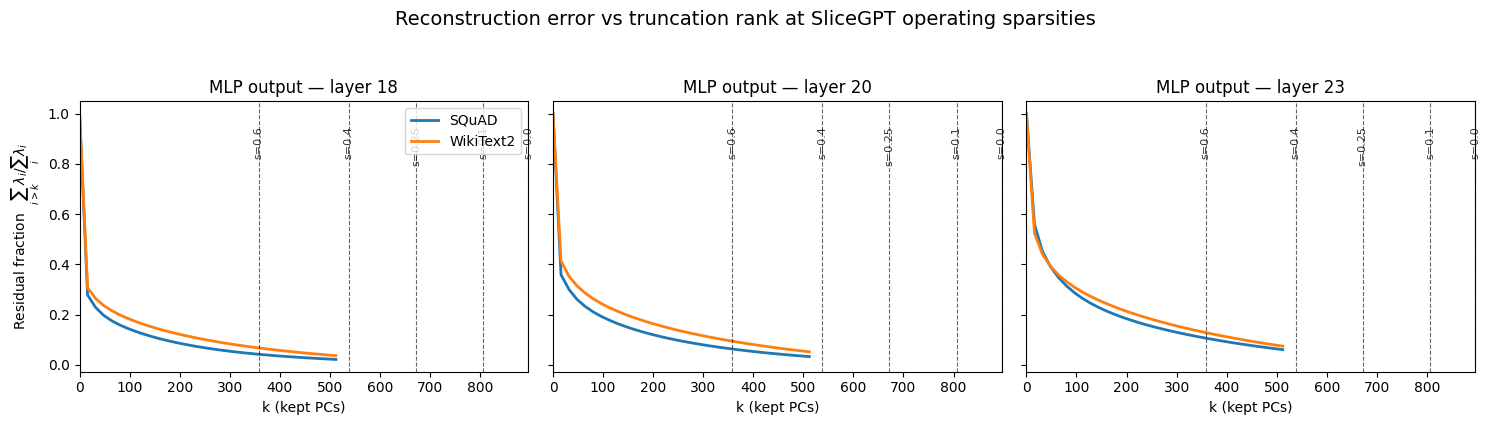

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# ---- config ----
LAYERS = [18, 20, 23]
d = 896
SPARSITIES = [0.6, 0.4, 0.25, 0.1, 0.0]
Ks = {s: int(round((1 - s) * d)) for s in SPARSITIES}

# ---- figure ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, li in zip(axes, LAYERS):
    sub = df_recon[df_recon["layer"] == li].sort_values("k")

    # curves
    ax.plot(sub["k"], sub["err_A"], label="SQuAD", linewidth=2)
    ax.plot(sub["k"], sub["err_B"], label="WikiText2", linewidth=2)

    # operating points
    for s, k_op in Ks.items():
        ax.axvline(k_op, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
        ax.text(
            k_op,
            0.95,
            f"s={s}",
            rotation=90,
            va="top",
            ha="center",
            fontsize=8,
            alpha=0.8
        )

    ax.set_title(f"MLP output — layer {li}")
    ax.set_xlabel("k (kept PCs)")
    ax.set_xlim(0, d)

axes[0].set_ylabel("Residual fraction  $\\sum_{i>k} \\lambda_i / \\sum_i \\lambda_i$")
axes[0].legend(loc="upper right")

plt.suptitle(
    "Reconstruction error vs truncation rank at SliceGPT operating sparsities",
    fontsize=14,
    y=1.05
)

plt.tight_layout()
plt.show()


In [60]:
import torch
import numpy as np

def to_token_matrix(list_of_tensors, max_tokens=None):
    X = torch.cat([t.detach().cpu().reshape(-1, t.shape[-1]).float()
                   for t in list_of_tensors], dim=0)
    if max_tokens is not None and X.shape[0] > max_tokens:
        X = X[:max_tokens]
    return X

def pca_basis_from_hidden(list_of_tensors, max_tokens=20000):
    """
    returns:
      mu: [d]
      Vh: [d,d] (rows are PCs; same as from torch.linalg.svd)
    """
    X = to_token_matrix(list_of_tensors, max_tokens=max_tokens)  # [T,d]
    mu = X.mean(dim=0)
    Xc = X - mu
    _, _, Vh = torch.linalg.svd(Xc, full_matrices=False)  # Vh: [d,d]
    return mu, Vh  # top-k are Vh[:k]


In [61]:
N_LAYERS = 24
MAX_TOKENS_CAL = 20000

basis_squad = {}
basis_wiki  = {}

for layer in range(N_LAYERS):
    key = f"layer_{layer}_mlp_output"
    basis_squad[layer] = pca_basis_from_hidden(hs_squad[key], max_tokens=MAX_TOKENS_CAL)
    basis_wiki[layer]  = pca_basis_from_hidden(hs_wiki[key],  max_tokens=MAX_TOKENS_CAL)

print("Built PCA bases from s=0.0 hidden states.")


Built PCA bases from s=0.0 hidden states.


In [62]:
d = 896
sparsity = 0.60
k = int(round((1 - sparsity) * d))
k


358

In [63]:
def make_mlp_projection_hook(mu_cpu, Vh_cpu, k, device, dtype):
    mu = mu_cpu.to(device=device, dtype=dtype)
    Vk = Vh_cpu[:k].T.contiguous().to(device=device, dtype=dtype)  # [d,k]
    P  = Vk @ Vk.T                                                 # [d,d]

    def hook(module, inp, out):
        # out: [B,S,d] in dtype (likely float16)
        return (out - mu) @ P + mu

    return hook


In [64]:
import numpy as np
import torch
import torch.nn.functional as F

def kl_token_mean(logits_p, logits_q, attention_mask=None):
    logp = F.log_softmax(logits_p, dim=-1)
    logq = F.log_softmax(logits_q, dim=-1)
    p = logp.exp()
    kl = (p * (logp - logq)).sum(dim=-1)  # [B,S]
    if attention_mask is not None:
        kl = kl * attention_mask
        return kl.sum() / (attention_mask.sum() + 1e-12)
    return kl.mean()

@torch.no_grad()
def layerwise_logit_kl(model, probe_loader, basis, k, device="cuda"):
    model.eval().to(device)
    dtype = next(model.parameters()).dtype  # <- fp16 most likely

    # --- baseline logits (computed once) ---
    base_logits_list, mask_list = [], []
    for batch in probe_loader:
        batch = {kk: vv.to(device) for kk, vv in batch.items()}
        out = model(**batch)
        base_logits_list.append(out.logits.detach().cpu())
        mask_list.append(batch.get("attention_mask", None).detach().cpu() if "attention_mask" in batch else None)

    base_logits = torch.cat(base_logits_list, dim=0)  # [Btot,S,V]
    mask = torch.cat(mask_list, dim=0) if mask_list[0] is not None else None

    # --- per-layer projection + KL ---
    kls = []
    for layer in range(len(basis)):
        mu, Vh = basis[layer]

        mlp_mod = model.model.layers[layer].mlp
        h = mlp_mod.register_forward_hook(
            make_mlp_projection_hook(mu, Vh, k, device=device, dtype=dtype)  # <- pass dtype
        )

        proj_logits_list = []
        for batch in probe_loader:
            batch = {kk: vv.to(device) for kk, vv in batch.items()}
            out = model(**batch)
            proj_logits_list.append(out.logits.detach().cpu())

        h.remove()

        proj_logits = torch.cat(proj_logits_list, dim=0)
        kl = kl_token_mean(base_logits, proj_logits, attention_mask=mask).item()
        kls.append(kl)
        print(f"layer {layer:02d}: KL={kl:.6f}")

    return np.array(kls)


In [65]:

import os, textwrap

# Where to save logs and models in your Drive
BASE_RESULTS_DIR = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments"
LOG_DIR = os.path.join(BASE_RESULTS_DIR, "logs_opt_pca/Qwen2-0.5B")
MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_opt_pca/Qwen2-0.5B")
BASE_EVAL_DIR = os.path.join(BASE_RESULTS_DIR, "eval")
SQUAD_ROT = os.path.join(MODEL_DIR,"squad_s0p00/Qwen2-0.5B_0.0_rotation_matrices.pt")
WIKI_ROT = os.path.join(MODEL_DIR,"wikitext2_s0p00/Qwen2-0.5B_0.0_rotation_matrices.pt")
SQUAD_HIDDEN = os.path.join(MODEL_DIR,"squad_s0p00/Qwen2-0.5B_0.0_squad_hidden_states.pt")
WIKI_HIDDEN = os.path.join(MODEL_DIR,"wikitext2_s0p00/Qwen2-0.5B_0.0_wikitext2_hidden_states.pt")


os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

In [66]:
import torch
from slicegpt import hf_utils
MODEL_NAME = "Qwen/Qwen2-0.5B"
SLICED_DIR  = os.path.join(MODEL_DIR,"squad_s0p00")

model_adapter, tokenizer = hf_utils.load_sliced_model(
    MODEL_NAME,
    SLICED_DIR,
    sparsity=0.0
)
model = model_adapter.model


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [67]:
device = "cuda"

model = model.to(device).eval()

inputs = tokenizer("Hello", return_tensors="pt").to(device)
with torch.no_grad():
    out = model(**inputs)

print(out.logits.shape)


torch.Size([1, 1, 151936])


In [68]:
mlp_mod = model.model.layers[layer].mlp

In [69]:
print(model.model.layers[0].mlp)


Qwen2MLP(
  (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
  (up_proj): Linear(in_features=896, out_features=4864, bias=False)
  (down_proj): Linear(in_features=4864, out_features=896, bias=False)
  (act_fn): SiLU()
)


In [70]:
from torch.utils.data import DataLoader

probe_texts = [
    "The capital of France is",
    "In physics, energy is defined as",
    "A neural network is a function that",
    "Munich is a city in Germany and",
] * 32  # 128 samples

def collate_fn(texts):
    return tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256
    )

probe_loader = DataLoader(probe_texts, batch_size=8, shuffle=False, collate_fn=collate_fn)


In [71]:
device = "cuda"
model = model.to(device).eval()

# pick k from sparsity you care about
d = 896
sparsity = 0.60
k = int(round((1 - sparsity) * d))

layer = 20
mu, Vh = basis_squad[layer]
dtype = next(model.parameters()).dtype

batch = next(iter(probe_loader))
batch = {kk: vv.to(device) for kk, vv in batch.items()}

with torch.no_grad():
    logits_base = model(**batch).logits

h = model.model.layers[layer].mlp.register_forward_hook(
    make_mlp_projection_hook(mu, Vh, k, device=device, dtype=dtype)
)

with torch.no_grad():
    logits_proj = model(**batch).logits

h.remove()

print("Mean abs diff:", (logits_base - logits_proj).abs().mean().item())


Mean abs diff: 0.7003824710845947


In [72]:
kl_squad = layerwise_logit_kl(model, probe_loader, basis_squad, k, device="cuda")
kl_wiki  = layerwise_logit_kl(model, probe_loader, basis_wiki,  k, device="cuda")


layer 00: KL=1.316858
layer 01: KL=0.652571
layer 02: KL=3.117451
layer 03: KL=0.831666
layer 04: KL=2.371590
layer 05: KL=1.475193
layer 06: KL=1.852210
layer 07: KL=1.248837
layer 08: KL=1.720315
layer 09: KL=1.542844
layer 10: KL=0.779466
layer 11: KL=0.145431
layer 12: KL=0.137527
layer 13: KL=0.115012
layer 14: KL=0.146161
layer 15: KL=0.134302
layer 16: KL=0.170321
layer 17: KL=0.156352
layer 18: KL=0.119712
layer 19: KL=0.111686
layer 20: KL=0.178420
layer 21: KL=0.514048
layer 22: KL=3.406158
layer 23: KL=0.965053
layer 00: KL=1.772571
layer 01: KL=0.765581
layer 02: KL=2.768186
layer 03: KL=0.940542
layer 04: KL=1.822317
layer 05: KL=1.592187
layer 06: KL=1.786136
layer 07: KL=1.283710
layer 08: KL=1.642084
layer 09: KL=1.481138
layer 10: KL=0.727322
layer 11: KL=0.237721
layer 12: KL=0.151197
layer 13: KL=0.131848
layer 14: KL=0.163984
layer 15: KL=0.153634
layer 16: KL=0.199270
layer 17: KL=0.169975
layer 18: KL=0.113179
layer 19: KL=0.123013
layer 20: KL=0.185961
layer 21: 

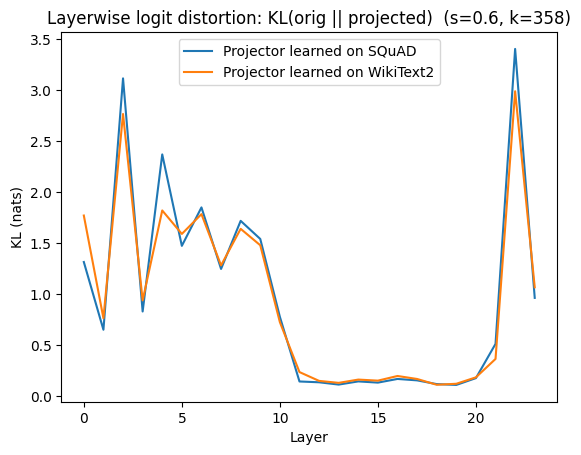

In [73]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(kl_squad, label="Projector learned on SQuAD")
plt.plot(kl_wiki,  label="Projector learned on WikiText2")
plt.title(f"Layerwise logit distortion: KL(orig || projected)  (s={sparsity}, k={k})")
plt.xlabel("Layer")
plt.ylabel("KL (nats)")
plt.legend()
plt.show()
